# Identificação de transações fraudulentas em cartões de crédito utilizando aprendizado de máquina não supervisionado

#### Integrantes do grupo:

* CAIO REBERT OLIVEIRA DA SILVA - 20260001876 
* GABRIEL SOARES DE VASCONCELOS LIRA - 20260001956  
* JADSON VINICIUS RAMOS DE SOUZA - 20230056158  
* SILAS EDUARDO RODRIGUES DOS SANTOS - 20260002167  

#### Importação das libs necessárias:

In [27]:
# instalação
!pip install pandas scikit-learn matplotlib

# importação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#### Funções utilitárias de limpeza e manipulação dos dados:

In [28]:
def limpar_e_normalizar_csv(caminho_entrada, caminho_saida):
    df = pd.read_csv(caminho_entrada, sep=',', dtype={'zip': str, 'merch_zipcode': str, 'cc_num': str})

    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    if 'trans_date_trans_time' in df.columns:
        df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
        df['trans_hour'] = df['trans_date_trans_time'].dt.hour
        df['trans_day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

    if 'dob' in df.columns:
        df['dob'] = pd.to_datetime(df['dob'])
        df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).round(0)

    colunas_texto = ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job']
    for col in colunas_texto:
        if col in df.columns:
            df[col] = df[col].fillna('não informado').astype(str).str.strip().str.lower()

    if 'city_pop' in df.columns:
        df['city_pop'] = df['city_pop'].fillna(df['city_pop'].median())

    df = df.dropna(subset=['lat', 'long', 'merch_lat', 'merch_long'])

    if 'is_fraud' in df.columns:
        df = df.dropna(subset=['is_fraud'])
        df['is_fraud'] = df['is_fraud'].astype(int)

    df.to_csv(caminho_saida, index=False, encoding='utf-8')
    print("Tratamento avançado para detecção de fraude concluído!")

#### Tratamento dos dados:

In [29]:
try:
    arquivo_sujo = "data/credit_card_transaction_train.csv"
    arquivo_limpo = "data/dados_limpos.csv"
    limpar_e_normalizar_csv(arquivo_sujo, arquivo_limpo)
except FileNotFoundError:
    print(f"Erro: O arquivo '{arquivo_sujo}' não foi encontrado. Altere os caminhos no código.")

Tratamento avançado para detecção de fraude concluído!


#### Exibição de informações sobre os dados:

##### Carregamento dos dados:

In [32]:
# Carregamento dos dados:
df = pd.read_csv("data/dados_limpos.csv", sep=",")

##### Informações do dataframe:

In [33]:
print('# Linhas e Colunas do Dataframe:')
print(df.shape)

print('')

print('# Primeiras linhas do Dataframe:')
df.head(3)

# Linhas e Colunas do Dataframe:
(1296675, 26)

# Primeiras linhas do Dataframe:


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_hour,trans_day_of_week,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_rippin, kub and mann",misc_net,4.97,jennifer,banks,f,561 perry cove,moravian falls,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,0,1,31.0
1,2019-01-01 00:00:44,630423337322,"fraud_heller, gutmann and zieme",grocery_pos,107.23,stephanie,gill,f,43039 riley greens suite 393,orient,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,0,1,41.0
2,2019-01-01 00:00:51,38859492057661,fraud_lind-buckridge,entertainment,220.11,edward,sanchez,m,594 white dale suite 530,malad city,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,0,1,57.0


In [34]:
print('# Informações do Dataframe:')
print(df.info())

# Informações do Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 26 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  str    
 6   last                   1296675 non-null  str    
 7   gender                 1296675 non-null  str    
 8   street                 1296675 non-null  str    
 9   city                   1296675 non-null  str    
 10  state                  1296675 non-null  str    
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  c

In [35]:
print('# Descrição do Dataframe:')
print(df.describe())

# Descrição do Dataframe:
             cc_num           amt           zip           lat          long  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01 -9.022634e+01   
std    1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00  1.375908e+01   
min    6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01 -1.656723e+02   
25%    1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01 -9.679800e+01   
50%    3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01 -8.747690e+01   
75%    4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01 -8.015800e+01   
max    4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01 -6.795030e+01   

           city_pop     unix_time     merch_lat    merch_long      is_fraud  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01  5.788652e-03   
std    3.019564e+05  1.28

##### Verificação de valores faltantes e únicos:

In [36]:
print('# Valores Faltantes por Coluna:')
print(df.isna().sum())

# Valores Faltantes por Coluna:
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
trans_hour                    0
trans_day_of_week             0
age                           0
dtype: int64


In [37]:
print('# Quantidade de Valores Únicos:')
print(df.nunique())

# Quantidade de Valores Únicos:
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
merch_zipcode              28336
trans_hour                    24
trans_day_of_week              7
age                           83
dtype: int64


#### Redução de Dimensionalidade:

##### Aplicação de PCA:

Usando DataFrame ja carregado: df
Base usada no PCA: 1296675 linhas e 9 variaveis numericas.
Variaveis consideradas: ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day_of_week', 'age']
Componentes para explicar 90% da variancia: 6
Componentes para explicar 95% da variancia: 7


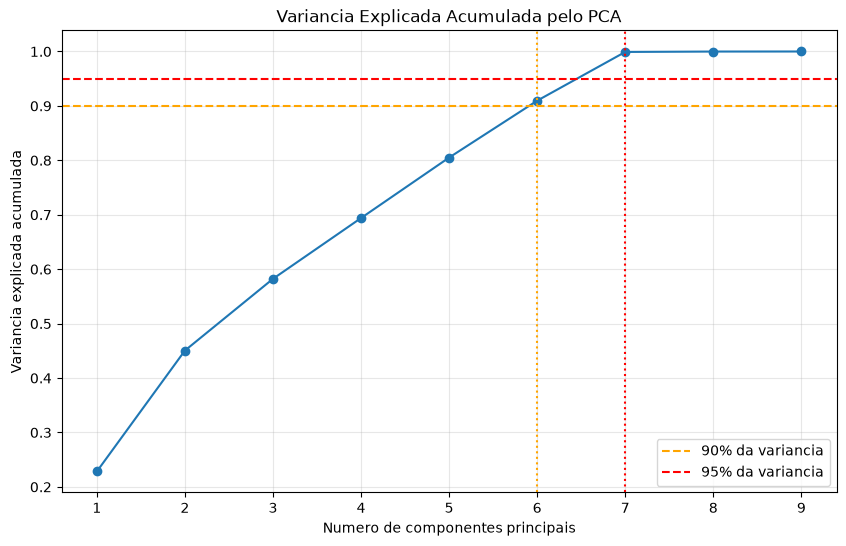

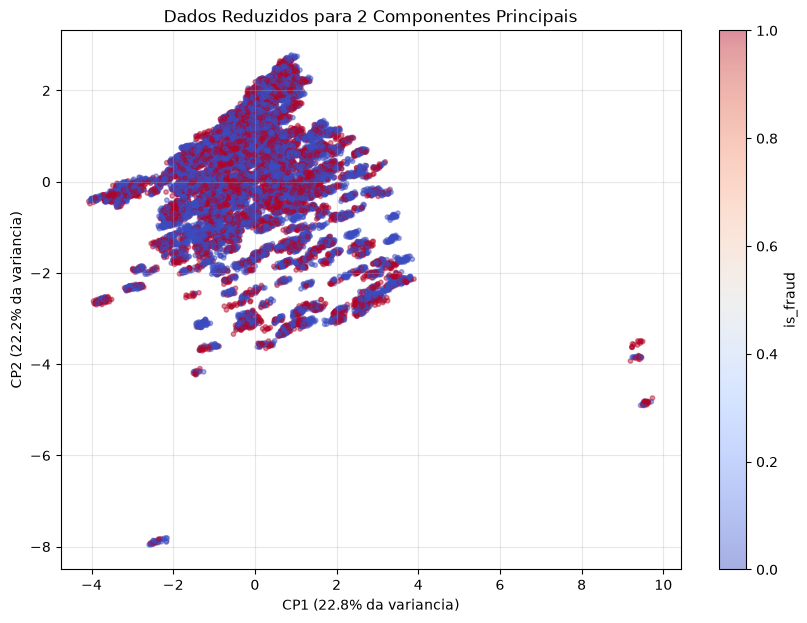

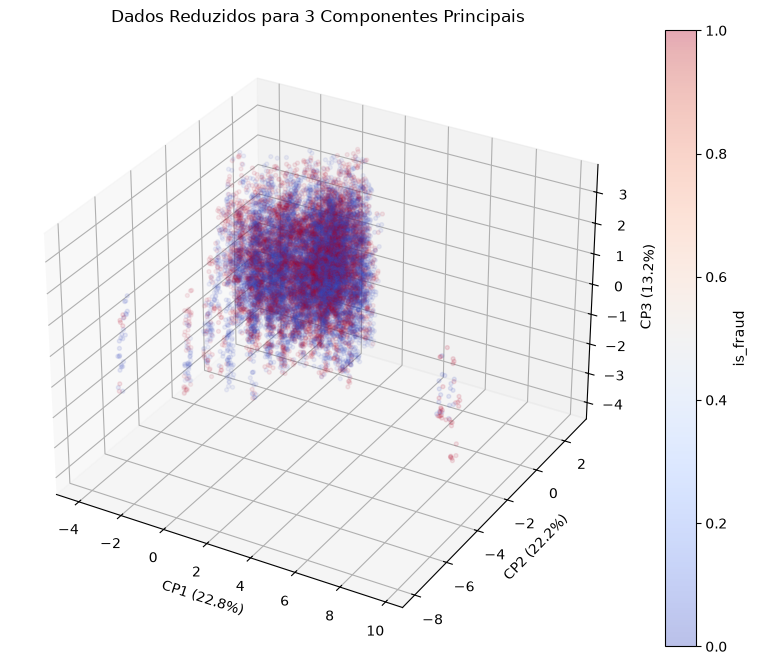

,PC1,PC2,is_fraud
0,-0.908048,0.664031,0
1,3.745247,-1.683017,0
2,1.995139,-1.685696,0
3,2.987973,-1.337113,0
4,-0.349833,1.136888,0


In [38]:
# Reducao de dimensionalidade com PCA

try:
    df_pca = df.copy()
    print("Usando DataFrame ja carregado: df")
except NameError:
    df_pca = pd.read_csv("data/dados_limpos.csv")
    print("DataFrame df nao encontrado. Carregando data/dados_limpos.csv")

# Remove alvo, identificadores e variaveis que nao devem orientar a reducao.
colunas_excluir = [
    "is_fraud", "unix_time", "cc_num", "zip", "merch_zipcode",
    "trans_date_trans_time", "dob"
]

X_numerico = df_pca.select_dtypes(include=[np.number]).drop(
    columns=[col for col in colunas_excluir if col in df_pca.columns],
    errors="ignore"
)

X_numerico = X_numerico.fillna(X_numerico.median())
nomes_features = X_numerico.columns.tolist()

# PCA e sensivel a escala, entao o escalonamento deve acontecer antes da reducao.
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X_numerico)

print(f"Base usada no PCA: {X_escalonado.shape[0]} linhas e {X_escalonado.shape[1]} variaveis numericas.")
print("Variaveis consideradas:", nomes_features)

# PCA com todos os componentes para analisar a variancia explicada acumulada.
pca_completo = PCA()
pca_completo.fit(X_escalonado)

variancia_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
n_componentes_90 = np.argmax(variancia_acumulada >= 0.90) + 1
n_componentes_95 = np.argmax(variancia_acumulada >= 0.95) + 1

print(f"Componentes para explicar 90% da variancia: {n_componentes_90}")
print(f"Componentes para explicar 95% da variancia: {n_componentes_95}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o")
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% da variancia")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% da variancia")
plt.axvline(x=n_componentes_90, color="orange", linestyle=":")
plt.axvline(x=n_componentes_95, color="red", linestyle=":")
plt.title("Variancia Explicada Acumulada pelo PCA")
plt.xlabel("Numero de componentes principais")
plt.ylabel("Variancia explicada acumulada")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Reducao para 2D e 3D.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_escalonado)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_escalonado)

cores = df_pca["is_fraud"].to_numpy() if "is_fraud" in df_pca.columns else None

# Amostragem para deixar os graficos leves. Se existir is_fraud, preserva todos os casos de fraude.
rng = np.random.default_rng(42)
limite_plot = 20000
todos_indices = np.arange(len(X_pca_2d))

if cores is not None:
    indices_fraude = todos_indices[cores == 1]
    indices_nao_fraude = todos_indices[cores == 0]
    qtd_nao_fraude = max(0, limite_plot - len(indices_fraude))
    indices_nao_fraude = rng.choice(
        indices_nao_fraude,
        size=min(qtd_nao_fraude, len(indices_nao_fraude)),
        replace=False
    )
    indices_plot = np.concatenate([indices_fraude, indices_nao_fraude])
else:
    indices_plot = rng.choice(
        todos_indices,
        size=min(limite_plot, len(todos_indices)),
        replace=False
    )

rng.shuffle(indices_plot)
cores_plot = cores[indices_plot] if cores is not None else None

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_2d[indices_plot, 0],
    X_pca_2d[indices_plot, 1],
    c=cores_plot,
    cmap="coolwarm",
    alpha=0.45,
    s=10
)
plt.title("Dados Reduzidos para 2 Componentes Principais")
plt.xlabel(f"CP1 ({pca_2d.explained_variance_ratio_[0]:.1%} da variancia)")
plt.ylabel(f"CP2 ({pca_2d.explained_variance_ratio_[1]:.1%} da variancia)")
plt.grid(alpha=0.3)

if cores is not None:
    plt.colorbar(scatter, label="is_fraud")

plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
grafico_3d = ax.scatter(
    X_pca_3d[indices_plot, 0],
    X_pca_3d[indices_plot, 1],
    X_pca_3d[indices_plot, 2],
    c=cores_plot,
    cmap="coolwarm",
    alpha=0.35,
    s=8
)
ax.set_title("Dados Reduzidos para 3 Componentes Principais")
ax.set_xlabel(f"CP1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"CP2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"CP3 ({pca_3d.explained_variance_ratio_[2]:.1%})")

if cores is not None:
    fig.colorbar(grafico_3d, ax=ax, label="is_fraud")

plt.show()

# DataFrames com os dados reduzidos, para usar nas proximas etapas.
df_pca_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])

if cores is not None:
    df_pca_2d["is_fraud"] = cores
    df_pca_3d["is_fraud"] = cores

df_pca_2d.head()


##### Interpretação dos Resultados:

Nesta etapa, foi aplicada a Análise de Componentes Principais (PCA) sobre os dados numéricos já limpos e escalonados. A base utilizada possui **1.296.675 registros** e **9 variáveis numéricas**: `amt`, `lat`, `long`, `city_pop`, `merch_lat`, `merch_long`, `trans_hour`, `trans_day_of_week` e `age`.

O gráfico de variância explicada acumulada mostra quanto da informação original dos dados é preservada à medida que aumentamos o número de componentes principais. Observa-se que:

- Com **6 componentes principais**, o modelo preserva aproximadamente **90% da variância** dos dados.
- Com **7 componentes principais**, o modelo preserva aproximadamente **95% da variância** dos dados.

Isso indica que é possível reduzir a dimensionalidade da base de 9 variáveis para 6 ou 7 componentes, mantendo a maior parte da informação original. Para uma redução mais compacta, 6 componentes já representam bem os dados. Para preservar mais informação, 7 componentes são uma escolha mais segura.

Nas visualizações em 2D e 3D, os dados foram projetados nos primeiros componentes principais. No gráfico 2D, os dois primeiros componentes explicam cerca de **45% da variância total** dos dados, sendo **22,8% pelo CP1** e **22,2% pelo CP2**. Já no gráfico 3D, os três primeiros componentes explicam aproximadamente **58,2% da variância total**, somando **22,8% do CP1**, **22,2% do CP2** e **13,2% do CP3**.

As cores representam a variável `is_fraud`, em que `0` indica transações não fraudulentas e `1` indica transações fraudulentas. Visualmente, percebe-se que as transações fraudulentas aparecem misturadas às transações normais, sem uma separação linear clara apenas com os primeiros componentes principais. Isso sugere que a fraude não é facilmente distinguida somente por uma projeção PCA em 2D ou 3D.

Mesmo assim, o PCA é útil porque reduz a quantidade de variáveis e cria uma representação mais compacta dos dados, que pode ser utilizada nas próximas etapas, como algoritmos de agrupamento ou detecção de anomalias.